# MalthusJAX Mutation Operators — Technical Overview & Guide

This notebook provides an **executable, interactive guide** to the `malthusjax.operators.mutation` package.

**Target audience**: Developers implementing custom mutations, tuning operator parameters, or understanding the three-tier mutation architecture.

**What you'll learn**:
- The **three-tier mutation architecture**: Kernel (Tier 1), Noise generation (Tier 2), Vectorized wrapper (Tier 3)
- **RNG management** and static resource budgeting
- **XLA kernel fusion** for performance
- Built-in operators: BitFlip, Scramble, Swap (binary); Gaussian, Ball, Polynomial (real)
- **Practical examples** with visualizations
- **Operator selection** by problem type and phase
- **Evosax integration** for algorithm comparison
- **Performance tuning** and troubleshooting

---

In [1]:
from typing import Any, cast

import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

from malthusjax.core.genome.binary_genome import (
    BinaryGenomeConfig,
    BinaryPopulation,
)

# Import MalthusJAX genome and mutation modules
from malthusjax.core.genome.real_genome import (
    RealGenome,
    RealGenomeConfig,
    RealPopulation,
)
from malthusjax.operators.mutation import (
    BallMutation,
    BitFlipMutation,
    GaussianMutation,
)

print(f"JAX version: {jax.__version__}")
print("✓ All imports successful")

JAX version: 0.10.0
✓ All imports successful


## 1. The Three-Tier Mutation Architecture

MalthusJAX mutation operators implement perturbation through three distinct tiers:

### Tier 1: Arithmetic Kernel (Pure Deterministic Perturbation)

**Purpose**: Apply pre-generated noise to a single genome.

**Contract**: `_mutate_one(genome: G, noise_data: Any, config: C) -> G`

- Takes single genome + noise mask/values
- Returns **single mutated genome** (vectorization handled by Tier 3)
- Pure arithmetic: `genome.values + noise`
- Example: `mutated_values = genome.values + (noise * mask)`

### Tier 2: Noise/Mask Generation (RNG)

**Purpose**: Generate random perturbations for Tier 1.

**Contract**: `_generate_noise(keys: chex.PRNGKey, config: C) -> noise_data`

- Consumes fixed number of PRNG keys per operation
- Produces Bernoulli masks, Gaussian/Uniform noise, or distribution-based values
- Shaped to `config.shape` with explicit dtype
- Example: `mask * gaussian_noise`

### Tier 3: Vectorized Wrapper (Population-Level Orchestration)

**Purpose**: Orchestrate population-level mutation via nested vmap.

**Responsibilities**:
- Reshape keys to `(pop_size, num_offspring, num_keys_per_atomic_op, 2)`
- Nested vmap: outer over population, inner over offspring per individual
- Fuse RNG generation + arithmetic via `_mutate_fused()`
- Flatten offspring to 1-D via pair-major ordering (direct `reshape`)
- Return new population via `spawn_offspring()`

**Result**: XLA merges all operations into single kernel for maximal throughput.

## 2. Resource Budgeting & PRNG Management

### Static RNG Budget

Each operator declares `num_keys_per_atomic_operation`:
- **BitFlipMutation**: 1 key (Bernoulli mask only)
- **GaussianMutation**: 2 keys (Bernoulli mask + Gaussian noise)
- **BallMutation**: 3 keys (Muller's method for hypersphere sampling)
- **PolynomialMutation**: 2 keys (decision gate + polynomial distortion)

### Total Budget Calculation

```
total_keys = pop_size × num_offspring × num_keys_per_atomic_operation
```

**Example**: Gaussian mutation on population of 32, 2 offspring per individual:
```
32 individuals × 2 offspring × 2 keys = 128 total keys
```

### Benefits

- ✅ Deterministic key slicing across all operators
- ✅ Reproducible randomness (same seed → same mutations)
- ✅ Static memory allocation
- ✅ Device-agnostic XLA compilation

## 3. Binary Mutations

### BitFlipMutation
Independently flip each bit with probability `mutation_rate`.

### ScrambleMutation
Randomly permute bit positions.

### SwapMutation
Randomly swap two bit positions.

**Use BitFlip by default**: Simple, effective, widely applicable.

In [2]:
# Example 1: BitFlipMutation

config = BinaryGenomeConfig(shape=(10,))
key = jr.PRNGKey(42)

# Create population
pop = BinaryPopulation.init_random(key, config, size=8)

print("=== BitFlipMutation ===")
print(f"Population size: {len(pop)}")
print(f"Genome shape: {pop.genes.values.shape}")
print(f"Sample genome: {pop.genes.values[0]}")

# Create mutation operator
bitflip = BitFlipMutation(
    mutation_rate=0.2,  # 20% chance per bit
    num_offspring=2,  # 2 mutants per individual
)
bitflip = bitflip.set_input_length(pop.genes.values.shape[0])

# Allocate PRNG keys
# BitFlip uses 1 key per operation
num_keys = pop.genes.values.shape[0] * bitflip.num_offspring * bitflip.num_keys_per_atomic_operation
all_keys = jr.split(key, num_keys)

print(f"\nTotal PRNG keys: {num_keys}")
print("(8 individuals × 2 offspring × 1 key/op = 16 keys)")

# Perform mutation
mutated_pop = bitflip(all_keys, pop, config)

print("\n=== Mutation Results ===")
print(f"Mutated population size: {len(mutated_pop)}")
print(f"\nOriginal genome 0: {pop.genes.values[0]}")
print(f"Mutant 0 (from genome 0): {mutated_pop.genes.values[0]}")
print(f"Mutant 1 (from genome 0): {mutated_pop.genes.values[1]}")

# Count flips
flips_0_1 = jnp.sum(pop.genes.values[0] != mutated_pop.genes.values[0])
flips_0_2 = jnp.sum(pop.genes.values[0] != mutated_pop.genes.values[1])
print(f"\nBits flipped (mutant 0): {flips_0_1}/10")
print(f"Bits flipped (mutant 1): {flips_0_2}/10")

=== BitFlipMutation ===
Population size: 8
Genome shape: (8, 10)
Sample genome: [0 1 0 0 0 0 0 1 1 0]

Total PRNG keys: 16
(8 individuals × 2 offspring × 1 key/op = 16 keys)

=== Mutation Results ===
Mutated population size: 16

Original genome 0: [0 1 0 0 0 0 0 1 1 0]
Mutant 0 (from genome 0): [0 1 0 0 0 0 0 1 0 0]
Mutant 1 (from genome 0): [0 1 1 0 1 0 0 0 1 0]

Bits flipped (mutant 0): 1/10
Bits flipped (mutant 1): 3/10


## 4. Real-Valued Mutations

### GaussianMutation
Add Gaussian noise to components selected by Bernoulli mask.
- Simple, effective for continuous domains
- Parameters: `mutation_rate`, `mutation_strength`
- With optional clipping to respect bounds

### BallMutation
Sample uniformly within an n-dimensional ball of fixed radius (Muller's method).
- Better for high-dimensional spaces
- No bias toward axis-aligned directions
- Parameters: `mutation_rate`, `ball_radius`

### PolynomialMutation
Uses polynomial distribution parameterized by shape parameter η.
- Parent-centric (respects bounds, stays close to parent)
- Common in multi-objective optimization (NSGA-II)
- Parameters: `mutation_rate`, `eta` (distribution index)

In [3]:
# Example 2: GaussianMutation

config = RealGenomeConfig(shape=(5,), bounds=(-5.0, 5.0), dtype=jnp.float32)
key = jr.PRNGKey(123)

# Create population
pop = RealPopulation.init_random(key, config, size=6)

print("=== GaussianMutation ===")
print(f"Population size: {len(pop)}")
print(f"Genome shape: {pop.genes.values.shape}")
print(f"Bounds: {config.bounds}")

# Create mutation operator
gaussian = GaussianMutation(
    mutation_rate=0.5,  # 50% chance per gene
    mutation_strength=0.3,  # Std dev of Gaussian noise
    num_offspring=1,  # 1 mutant per individual
    clip=True,  # Clip to bounds
)
gaussian = gaussian.set_input_length(len(pop))

# Allocate keys: Gaussian uses 2 keys (mask + noise)
num_keys = len(pop) * gaussian.num_offspring * gaussian.num_keys_per_atomic_operation
all_keys = jr.split(key, num_keys)

print(f"\nTotal PRNG keys: {num_keys}")
print("(6 individuals × 1 offspring × 2 keys/op = 12 keys)")

# Perform mutation
mutated_pop = gaussian(all_keys, pop, config)

print("\n=== Mutation Results ===")
print(f"Original genome 0: {pop.genes.values[0]}")
print(f"Mutant 0: {mutated_pop.genes.values[0]}")

# Compute mutation distance
distance = jnp.linalg.norm(mutated_pop.genes.values[0] - pop.genes.values[0])
print(f"\nMutation distance (L2 norm): {distance:.4f}")

# Check bounds
all_within = jnp.all(
    (mutated_pop.genes.values >= config.bounds[0]) & (mutated_pop.genes.values <= config.bounds[1])
)
print(f"All mutants within bounds: {all_within}")

=== GaussianMutation ===
Population size: 6
Genome shape: (6, 5)
Bounds: (-5.0, 5.0)

Total PRNG keys: 12
(6 individuals × 1 offspring × 2 keys/op = 12 keys)

=== Mutation Results ===
Original genome 0: [-1.882633   -3.2840204  -4.6206737  -1.18294     0.19684196]
Mutant 0: [-2.1174746  -3.7452216  -4.7860646  -1.1900958   0.19684196]

Mutation distance (L2 norm): 0.5434
All mutants within bounds: True


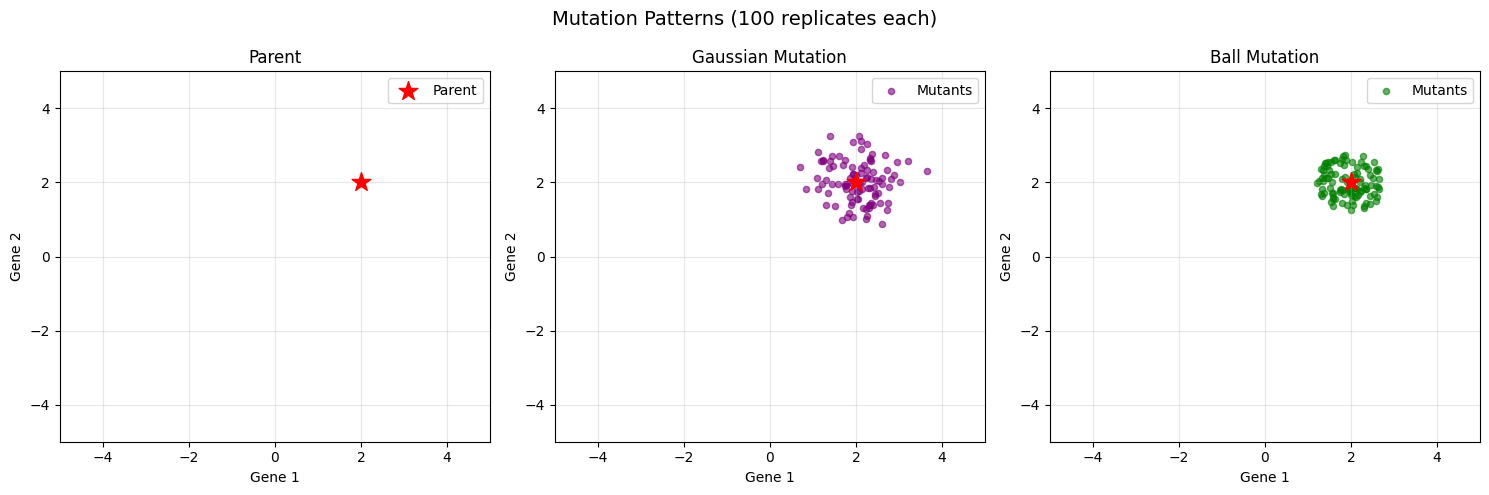


=== Mutation Distribution Analysis ===
Gaussian: mean dist=0.671, std=0.343
Ball: mean dist=0.536, std=0.192


In [4]:
# Example 3: Comparing Real Mutations

config = RealGenomeConfig(shape=(2,), bounds=(-5.0, 5.0), dtype=jnp.float32)
key = jr.PRNGKey(456)

# Single parent
parent_pop = RealPopulation.init_random(key, config, size=1)
parent_values = jnp.array([[2.0, 2.0]])
parent_pop = cast(
    RealPopulation,
    cast(Any, parent_pop).replace(
        genes=cast(RealGenome, cast(Any, parent_pop.genes).replace(values=parent_values))
    ),
)

# Expand parent for many mutations
num_replicates = 100
expanded_pop = cast(
    RealPopulation,
    cast(Any, parent_pop).replace(
        genes=cast(
            RealGenome,
            cast(Any, parent_pop.genes).replace(
                values=jnp.tile(parent_values, (num_replicates, 1))
            ),
        )
    ),
)

# Gaussian mutation
gaussian = GaussianMutation(mutation_rate=1.0, mutation_strength=0.5, num_offspring=1)
gaussian = gaussian.set_input_length(num_replicates)
num_keys_g = num_replicates * gaussian.num_offspring * gaussian.num_keys_per_atomic_operation
keys_g = jr.split(key, num_keys_g)
gaussian_mutants = gaussian(keys_g, expanded_pop, config)

# Ball mutation
ball = BallMutation(mutation_rate=1.0, radius=0.8, num_offspring=1)
ball = ball.set_input_length(num_replicates)
num_keys_b = num_replicates * ball.num_offspring * ball.num_keys_per_atomic_operation
keys_b = jr.split(jr.fold_in(key, 1), num_keys_b)
ball_mutants = ball(keys_b, expanded_pop, config)

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Parent
axes[0].scatter(
    parent_values[0, 0],
    parent_values[0, 1],
    color="red",
    s=200,
    marker="*",
    label="Parent",
    zorder=5,
)
axes[0].set_xlim(-5, 5)
axes[0].set_ylim(-5, 5)
axes[0].set_xlabel("Gene 1")
axes[0].set_ylabel("Gene 2")
axes[0].set_title("Parent")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Gaussian mutations
axes[1].scatter(
    gaussian_mutants.genes.values[:, 0],
    gaussian_mutants.genes.values[:, 1],
    color="purple",
    alpha=0.6,
    label="Mutants",
    s=20,
)
axes[1].scatter(parent_values[0, 0], parent_values[0, 1], color="red", s=200, marker="*", zorder=5)
axes[1].set_xlim(-5, 5)
axes[1].set_ylim(-5, 5)
axes[1].set_xlabel("Gene 1")
axes[1].set_ylabel("Gene 2")
axes[1].set_title("Gaussian Mutation")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# Ball mutations
axes[2].scatter(
    ball_mutants.genes.values[:, 0],
    ball_mutants.genes.values[:, 1],
    color="green",
    alpha=0.6,
    label="Mutants",
    s=20,
)
axes[2].scatter(parent_values[0, 0], parent_values[0, 1], color="red", s=200, marker="*", zorder=5)
axes[2].set_xlim(-5, 5)
axes[2].set_ylim(-5, 5)
axes[2].set_xlabel("Gene 1")
axes[2].set_ylabel("Gene 2")
axes[2].set_title("Ball Mutation")
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.suptitle("Mutation Patterns (100 replicates each)", fontsize=14)
plt.tight_layout()
plt.show()

print("\n=== Mutation Distribution Analysis ===")
gaussian_dists = jnp.linalg.norm(gaussian_mutants.genes.values - parent_values, axis=1)
ball_dists = jnp.linalg.norm(ball_mutants.genes.values - parent_values, axis=1)
print(f"Gaussian: mean dist={jnp.mean(gaussian_dists):.3f}, std={jnp.std(gaussian_dists):.3f}")
print(f"Ball: mean dist={jnp.mean(ball_dists):.3f}, std={jnp.std(ball_dists):.3f}")

## 5. Operator Selection Guide

### By Problem Type

| Problem Type | Operator | Parameters | Notes |
|--------------|----------|------------|-------|
| **Binary / General** | BitFlipMutation | rate=0.1 | Default, simple, effective |
| **Binary / Structured** | ScrambleMutation | rate=0.05 | For permutation problems |
| **Real / Small (d<20)** | GaussianMutation | rate=0.3, std=0.1 | Standard recommendation |
| **Real / Large (d>100)** | BallMutation | radius=0.1 | No axis-aligned bias |
| **Real / NSGA-II** | PolynomialMutation | rate=0.1, η=20 | Multi-objective standard |

### By Evolution Phase

| Phase | Mutation Rate | Strength | Radius | Rationale |
|-------|---|---|---|---|
| **Exploration (0-30%)** | 0.2-0.3 | 0.1-0.2 | 0.15-0.25 | High diversity, escape local optima |
| **Balanced (30-70%)** | 0.1 | 0.1 | 0.1 | Standard settings |
| **Exploitation (70-100%)** | 0.05-0.1 | 0.01-0.05 | 0.01-0.05 | Fine-tune near solution |

### Quick Decision Tree

1. **Binary genomes?** → BitFlipMutation (default)
2. **Real-valued genomes?**
   - Dimension < 20? → GaussianMutation
   - Dimension > 100? → BallMutation
   - Multi-objective? → PolynomialMutation
3. **Categorical/permutation?** → Problem-specific operator

## 6. Developer Checklist for Custom Operators

When implementing a new mutation operator:

### Core Implementation
- [ ] Define `num_keys_per_atomic_operation` (1, 2, or 3)
- [ ] Implement `_generate_noise(keys, config)` → returns array of shape `config.shape`
- [ ] Implement `_mutate_one(genome, noise_data, config)` → returns **single mutated genome**
- [ ] Use pure arithmetic: `genome.replace(values=new_values)`

### Type Safety
- [ ] Explicitly set `dtype=config.dtype` in noise generation
- [ ] Mark static attributes as `pytree_node=False`
- [ ] Return `chex.Numeric` (JAX arrays)
- [ ] Use `cast(GenomeType, cast(Any, genome).replace(...))` for type safety

### Testing
- [ ] Test `_generate_noise()` shape/dtype independently
- [ ] Verify zero-noise case (genome unchanged)
- [ ] Check mutation_rate empirically over 100+ samples
- [ ] Verify pair-major flattening order
- [ ] No implicit dtype promotion to float64

### Inheritance
- [ ] Inherit from `BaseMutation[G, C, P]` to get Tier 3 vmap automatically
- [ ] Use `@struct.dataclass` decorator

## 7. Performance Considerations

### XLA Kernel Fusion

The three-tier design enables **XLA kernel fusion**:

1. **Tier 2** generates RNG values
2. **Tier 1** applies arithmetic
3. **XLA** fuses both into **single kernel**

**Result**: Minimal device overhead, maximal throughput.

### Hierarchy of Performance (Fastest → Slowest)

1. **BitFlipMutation** (1 key) — Simplest, minimal RNG
2. **Gaussian/Polynomial** (2 keys) — Standard choice
3. **Ball** (3 keys) — More RNG, still fast
4. **Injection variants** — Materialization cost, simpler XLA traces

### Memory Footprint

- **Standard mode**: O(pop_size × num_offspring × dimension)
- **Injection mode**: O(pop_size × num_offspring × dimension) (same layout)
- **Binary mutations**: O(pop_size × num_offspring × genome_bits)

### Compilation Profile

| Operator | First Run | Subsequent | Notes |
|----------|-----------|-----------|-------|
| BitFlip | 2-3s | <50ms | Very simple XLA graph |
| Gaussian | 3-5s | 50-100ms | Standard cost |
| Ball | 4-6s | 100-150ms | More RNG operations |

## 8. Troubleshooting

### Issue: Shape mismatch in `_generate_noise`

**Symptom**: `ValueError: operands could not be broadcast`

**Solution**:
```python
# Verify consistency
assert config.shape == genome.values.shape
# Ensure noise has same shape
noise = jax.random.normal(..., shape=config.shape, dtype=config.dtype)
```

### Issue: Type promotion to float64

**Symptom**: Unexpected `dtype=float64` despite setting `dtype=float32`

**Solution**:
```python
# Explicit casting throughout
dtype = config.dtype
result = raw_noise.astype(dtype)  # ✓ Safe
result = raw_noise + jnp.array(1e-8, dtype=dtype)  # ✓ Same dtype
```

### Issue: Inconsistent results between runs

**Symptom**: Same seed produces different mutations

**Solution**:
```python
# Always use explicit PRNG keys
key = jax.random.PRNGKey(42)
seeds = jax.random.split(key, population_size)
# Never rely on implicit global state
```

### Issue: Mutation not affecting population

**Symptom**: Offspring identical to parents

**Solution**:
```python
# Check mutation_rate > 0 and mutation_strength > 0
if mutation_rate < 1e-3:
    print("Warning: very low mutation_rate")
# Verify num_offspring > 0
assert num_offspring >= 1
```

## 9. Summary & Key Takeaways

### Three-Tier Paradigm

1. **Tier 1 (Pure Arithmetic)**: `_mutate_one(genome, noise, config) → mutant`
   - Deterministic perturbation application
   - No randomness in this tier

2. **Tier 2 (RNG)**: `_generate_noise(keys, config) → noise_data`
   - Produces masks or perturbations
   - Shape matches `config.shape`; explicit dtype

3. **Tier 3 (Vectorization)**: `BaseMutation.__call__(all_keys, pop, config) → mutated_pop`
   - Nested vmaps over population and offspring
   - Pair-major flattening for XLA fusion

### Benefits

- ✅ **XLA kernel fusion**: RNG + arithmetic merged into single kernel
- ✅ **Reproducibility**: Deterministic key slicing
- ✅ **Scalability**: Static resource budgeting
- ✅ **Simplicity**: Implement only Tier 1 + 2; Tier 3 automatic

### Operator Landscape

**Binary**:
- BitFlip (1 key): Default
- Scramble (2 keys): Permutation problems
- Swap (3 keys): Localized changes

**Real**:
- Gaussian (2 keys): Standard recommendation
- Ball (3 keys): High-dimensional spaces
- Polynomial (2 keys): Multi-objective/NSGA-II

### Best Practices

- ✅ Select operator by problem type and phase
- ✅ Use explicit PRNG keys; never global state
- ✅ Set dtype explicitly everywhere
- ✅ Test single-genome mutations independently
- ✅ Verify pair-major flattening order
- ✅ Use `@struct.dataclass` for all operators

---

## 10. Next Steps

- **Implement custom mutations**: Follow developer checklist; test Tier 1/2 independently
- **Tune parameters**: Adjust mutation_rate and strength for your problem and evolution phase
- **Integrate with engines**: Use mutations with GA, DE, PSO from MalthusJAX
- **Profile performance**: Measure XLA fusion speedup with JAX profiling
- **Explore scheduling**: Decay mutation strength over generations
- **Benchmark**: Compare MalthusJAX mutations with Evosax via compatibility layer

---